# Linear Regression on CABA Housing Prices

Implementation of three methods to solve the linear regression problem:
- Normal Equations
- Batch Gradient Descent  
- Stochastic Gradient Descent

We start with a simple univariate regression using `metros` as the 
only feature to predict `precio`.

## Dataset
Scraped from ZonaProp, cleaned and processed. 32,585 properties 
in Buenos Aires (CABA).

### Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [20]:
df = pd.read_csv("data/zonaprop_clean.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (32585, 7)


,precio,expensas,metros,ambientes,banos,barrio,comuna
0,530000.0,770000,172.0,4.0,3.0,PALERMO,14
1,170000.0,0,73.0,4.0,1.0,VILLA CRESPO,15
2,120000.0,260000,54.0,3.0,1.0,RECOLETA,2
3,220000.0,380073,68.0,3.0,2.0,NUÑEZ,13
4,84100.0,110000,55.0,1.0,1.0,VILLA LURO,10


### Extract feature and target

In [21]:
X = df["metros"].values
y = df["precio"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nX range: {X.min():.0f} - {X.max():.0f} m²")
print(f"y range: USD {y.min():,.0f} - USD {y.max():,.0f}")

X shape: (32585,)
y shape: (32585,)

X range: 25 - 500 m²
y range: USD 54,900 - USD 2,500,000


Before fitting any model, let's visualize the relationship between 
`metros` and `precio`.

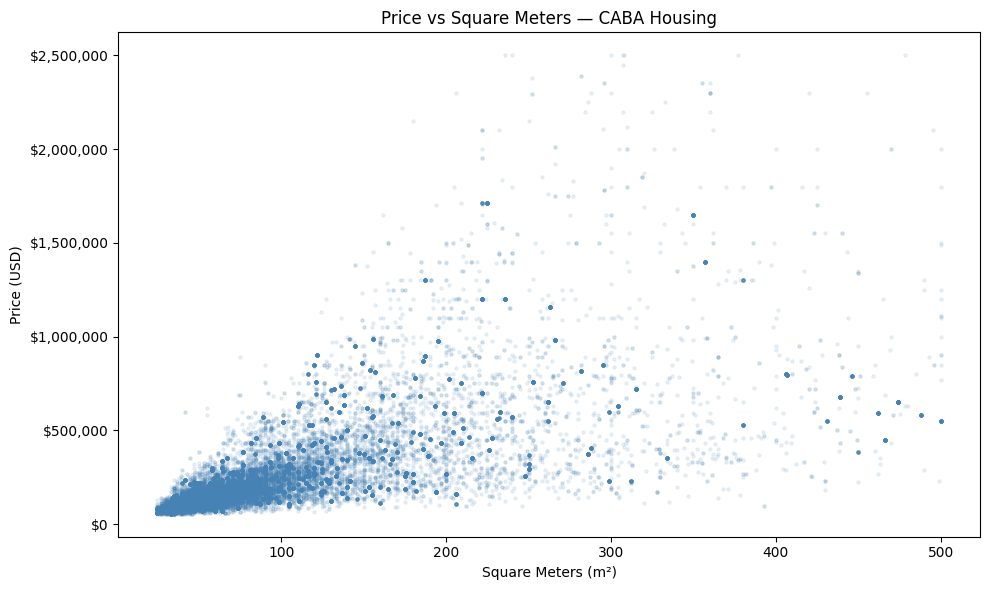

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.1, s=5, color="steelblue")
plt.title("Price vs Square Meters — CABA Housing")
plt.xlabel("Square Meters (m²)")
plt.ylabel("Price (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

### Normalize features

In [23]:
mu_X = X.mean()
sigma_X = X.std()
mu_y = y.mean()
sigma_y = y.std()

X_norm = (X - mu_X) / sigma_X
y_norm = (y - mu_y) / sigma_y

print(f"X — mean: {mu_X:.2f}, std: {sigma_X:.2f}")
print(f"y — mean: {mu_y:.2f}, std: {sigma_y:.2f}")

X — mean: 103.78, std: 80.12
y — mean: 276064.85, std: 257306.05


### Add bias term (column of ones)

This allows the model to learn an intercept $\theta_0$, so the regression 
line doesn't have to pass through the origin. Without it, 
the model would assume a property with 0 m² costs 
USD 0, which is unrealistic.

$$h_\theta(x) = \theta_0 + \theta_1 x$$
$$X_b = \begin{bmatrix} 1 & x^{(1)} \\ 1 & x^{(2)} \\ \vdots & \vdots \\ 1 & x^{(m)} \end{bmatrix}$$

In [24]:
X_b = np.column_stack([np.ones(len(X_norm)), X_norm])

print(f"X_b shape: {X_b.shape}")
print(f"\nFirst 5 rows of X_b:")
print(X_b[:5])

X_b shape: (32585, 2)

First 5 rows of X_b:
[[ 1.          0.85140939]
 [ 1.         -0.3841961 ]
 [ 1.         -0.62133251]
 [ 1.         -0.44660042]
 [ 1.         -0.60885165]]


### Train/Test Split

We split the dataset into 80% training and 20% test. The model learns 
from the training set and we evaluate performance on the test set,
data the model has never seen.

In [25]:
np.random.seed(42)
m = len(X_b)
indices = np.random.permutation(m)

train_size = int(0.8 * m)
train_idx = indices[:train_size]
test_idx  = indices[train_size:]

X_train, X_test = X_b[train_idx], X_b[test_idx]
y_train, y_test = y_norm[train_idx], y_norm[test_idx]

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 26,068
Test size:  6,517


### Cost Function

The cost function measures how well the model fits the data. 
We use the Mean Squared Error (MSE):

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

The $\frac{1}{2m}$ normalizes by the number of examples so the 
cost is comparable across different dataset sizes.

In [26]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = X @ theta
    error = predictions - y
    return (1 / (2 * m)) * np.sum(error ** 2)

## 1. Normal Equations

The normal equations give us the exact solution to the linear regression
problem in one shot — no iterations needed:

$$\theta = (X^TX)^{-1}X^Ty$$

This is the closed-form solution we derived analytically in PS0.

In [27]:
def normal_equations(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

theta_ne = normal_equations(X_train, y_train)
print(f"theta_0 (intercept):  {theta_ne[0]:,.2f}")
print(f"theta_1 (slope):      {theta_ne[1]:,.2f}")

theta_0 (intercept):  0.00
theta_1 (slope):      0.68


In [28]:
# Denormalize theta
x_cero_norm = (0 - mu_X) / sigma_X
theta0_real = (theta_ne[0] + theta_ne[1] * x_cero_norm) * sigma_y + mu_y
theta1_real = theta_ne[1] * sigma_y / sigma_X

print(f"theta_0 real (intercept at x=0): USD {theta0_real:,.2f}")
print(f"theta_1 real (slope):            USD {theta1_real:,.2f} per m²")

theta_0 real (intercept at x=0): USD 49,600.35
theta_1 real (slope):            USD 2,185.19 per m²


The model learns two parameters:
- **Intercept** $\theta_0 = 49,600$: the base price of a property 
  regardless of size.
- **Slope** $\theta_1 = 2,185$: each additional m² adds USD 2,185 
  to the price.

So the model predicts: $\text{price} = 49,600 + 2,185 \times \text{meters}$

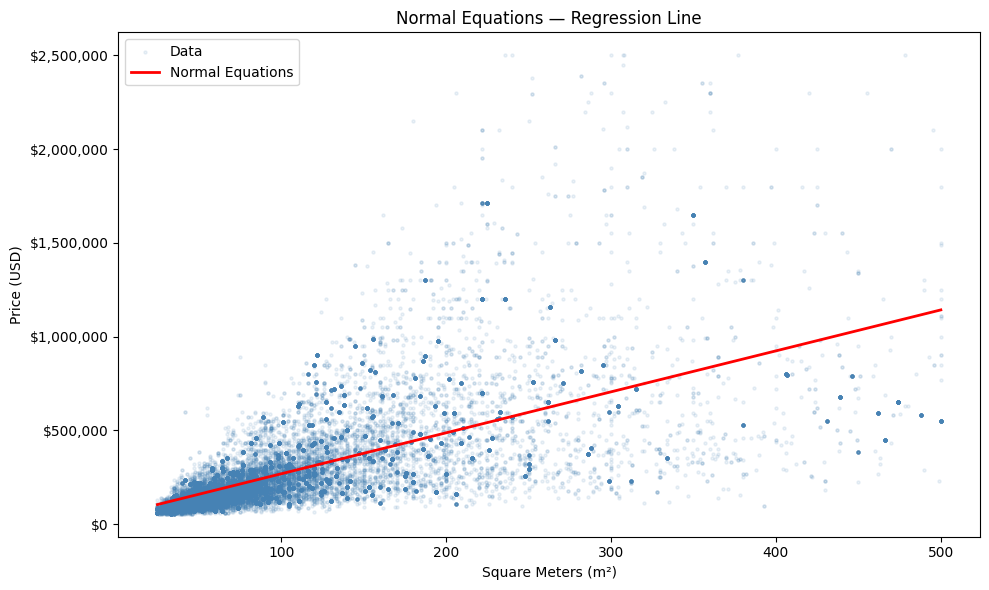

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter
ax.scatter(X, y, alpha=0.1, s=5, color="steelblue", label="Data")

# Regression line 
x_line_norm = (np.linspace(X.min(), X.max(), 100) - mu_X) / sigma_X
y_line = (theta_ne[0] + theta_ne[1] * x_line_norm) * sigma_y + mu_y

ax.plot(np.linspace(X.min(), X.max(), 100), y_line, 
        color="red", linewidth=2, label="Normal Equations")

ax.set_title("Normal Equations — Regression Line")
ax.set_xlabel("Square Meters (m²)")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

#### Evaluate using cost function

In [30]:
train_cost = cost_function(X_train, y_train, theta_ne)
test_cost = cost_function(X_test, y_test, theta_ne)

print(f"Train cost: {train_cost:,.2f}")
print(f"Test cost:  {test_cost:,.2f}")

Train cost: 0.27
Test cost:  0.26


#### Plotting cost function

In [31]:
# Grid 
theta0_vals = np.linspace(-0.5, 0.5, 100)
theta1_vals = np.linspace(0, 1.5, 100)
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        theta = np.array([t0, t1])
        J_vals[i, j] = cost_function(X_train, y_train, theta)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_grid = J_vals.T

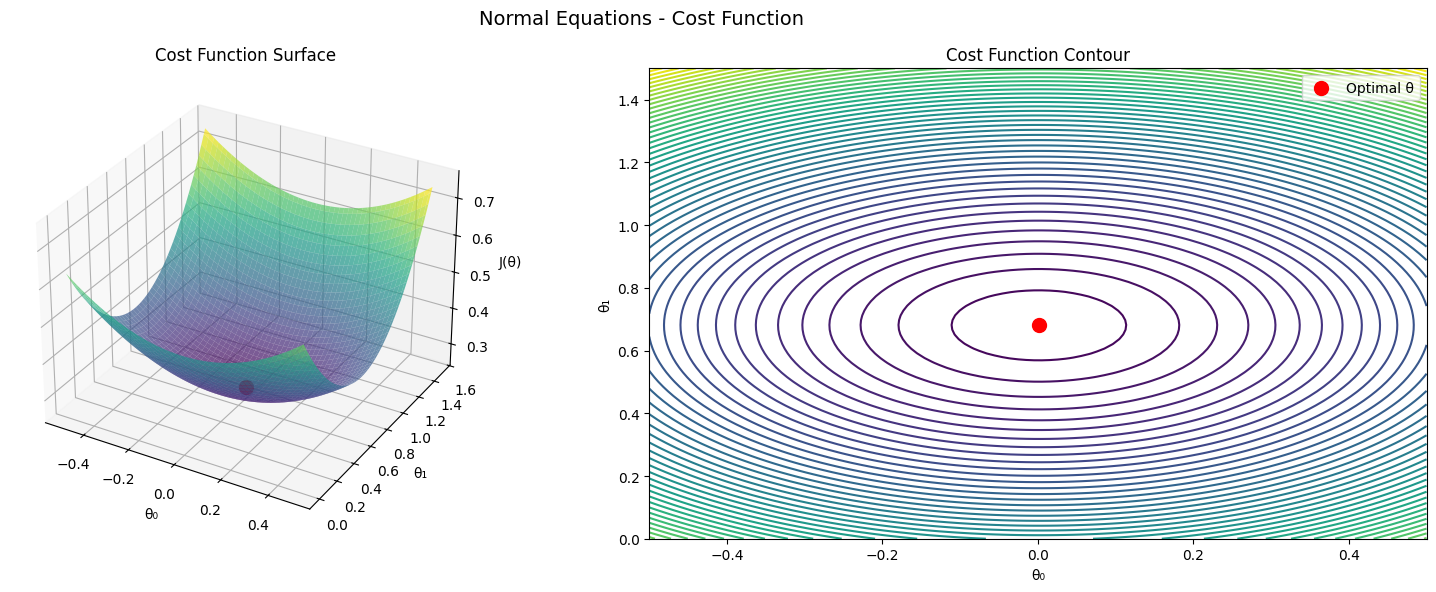

In [32]:
fig = plt.figure(figsize=(16, 6))

# 3D Surface
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(T0, T1, J_grid, cmap="viridis", alpha=0.7)
ax1.scatter(theta_ne[0], theta_ne[1], 
            cost_function(X_train, y_train, theta_ne),
            color="red", s=100, zorder=5, label="Optimal θ")
ax1.set_xlabel("θ₀")
ax1.set_ylabel("θ₁")
ax1.set_zlabel("J(θ)")
ax1.set_title("Cost Function Surface")

# Contour plot
ax2 = fig.add_subplot(122)
ax2.contour(T0, T1, J_grid, levels=50, cmap="viridis")
ax2.scatter(theta_ne[0], theta_ne[1], 
            color="red", s=100, zorder=5, label="Optimal θ")
ax2.set_xlabel("θ₀")
ax2.set_ylabel("θ₁")
ax2.set_title("Cost Function Contour")
ax2.legend()

plt.suptitle("Normal Equations - Cost Function", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Batch Gradient Descent

Unlike the normal equations, gradient descent is an iterative algorithm
that starts from a random point and takes steps in the direction of 
steepest descent until convergence.

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

Which expands to:

$$\theta_j := \theta_j - \frac{\alpha}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})x_j^{(i)}$$

Key hyperparameters:
- **Learning rate** $\alpha$: step size at each iteration
- **Iterations**: how many steps to take

In [33]:
def batch_gradient_descent(X, y, alpha, n_iterations):
    m = len(y)
    theta = np.zeros(2)          # initialize params in [0, 0]
    cost_history = []            # save cost in every iteration
    theta_history = [theta.copy()]  # save params 
    
    for i in range(n_iterations):
        # predictions
        predictions = X @ theta
        
        # error
        error = predictions - y
        
        gradient = (1/m) * X.T @ error
        theta = theta - alpha * gradient
        
        cost_history.append(cost_function(X, y, theta))
        theta_history.append(theta.copy())
    
    return theta, cost_history, theta_history

### Run Batch Gradient Descent

In [34]:
# Case 1: 10 iters
theta_bgd_10, cost_history_10, _ = batch_gradient_descent(X_train, y_train, 0.1, 10)
print(f"10 iter  -cost: {cost_history_10[-1]:.4f}, θ₁: {theta_bgd_10[1]:.4f}")

# Case 2: 100 iters
theta_bgd_100, cost_history_100, _ = batch_gradient_descent(X_train, y_train, 0.1, 100)
print(f"100 iter -cost: {cost_history_100[-1]:.4f}, θ₁: {theta_bgd_100[1]:.4f}")

# Case 3: 1000 iters
theta_bgd_1000, cost_history_1000, _ = batch_gradient_descent(X_train, y_train, 0.1, 1000)
print(f"1000 iter -cost: {cost_history_1000[-1]:.4f}, θ₁: {theta_bgd_1000[1]:.4f}")

# Normal Equations, just reference
print(f"NE        -cost: {cost_function(X_train, y_train, theta_ne):.4f}, θ₁: {theta_ne[1]:.4f}")

10 iter  -cost: 0.3015, θ₁: 0.4459
100 iter -cost: 0.2737, θ₁: 0.6804
1000 iter -cost: 0.2737, θ₁: 0.6804
NE        -cost: 0.2737, θ₁: 0.6804


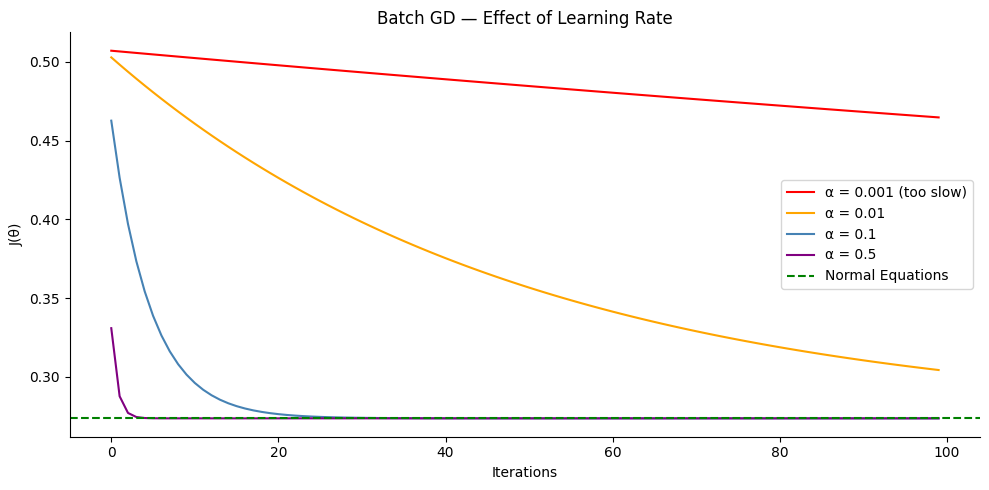

In [35]:
# same n_iterations, different learning rates
_, cost_lr_001, _ = batch_gradient_descent(X_train, y_train, 0.001, 100)
_, cost_lr_01,  _ = batch_gradient_descent(X_train, y_train, 0.01,  100)
_, cost_lr_1,   _ = batch_gradient_descent(X_train, y_train, 0.1,   100)
_, cost_lr_5,   _ = batch_gradient_descent(X_train, y_train, 0.5,   100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_lr_001, color="red",       label="α = 0.001 (too slow)")
ax.plot(cost_lr_01,  color="orange",    label="α = 0.01")
ax.plot(cost_lr_1,   color="steelblue", label="α = 0.1")
ax.plot(cost_lr_5,   color="purple",    label="α = 0.5")
ax.axhline(y=cost_function(X_train, y_train, theta_ne),
           color="green", linestyle="--", label="Normal Equations")
ax.set_title("Batch GD — Effect of Learning Rate")
ax.set_xlabel("Iterations")
ax.set_ylabel("J(θ)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

The learning rate $\alpha$ controls the step size at each iteration.
Too small and convergence is slow (α = 0.001 barely moves after 100 
iterations). Too large and the algorithm overshoots (α = 0.5 oscillates 
before converging). α = 0.1 finds the right balance — fast and smooth 
convergence to the Normal Equations solution.

### Final execution and cost function plots

In [36]:
alpha = 0.1
n_iterations = 1000

theta_bgd, cost_history_bgd, theta_history_bgd = batch_gradient_descent(
    X_train, y_train, alpha, n_iterations
)

theta_history_bgd = np.array(theta_history_bgd)
print(f"theta_history_bgd shape: {theta_history_bgd.shape}")

theta_history_bgd shape: (1001, 2)


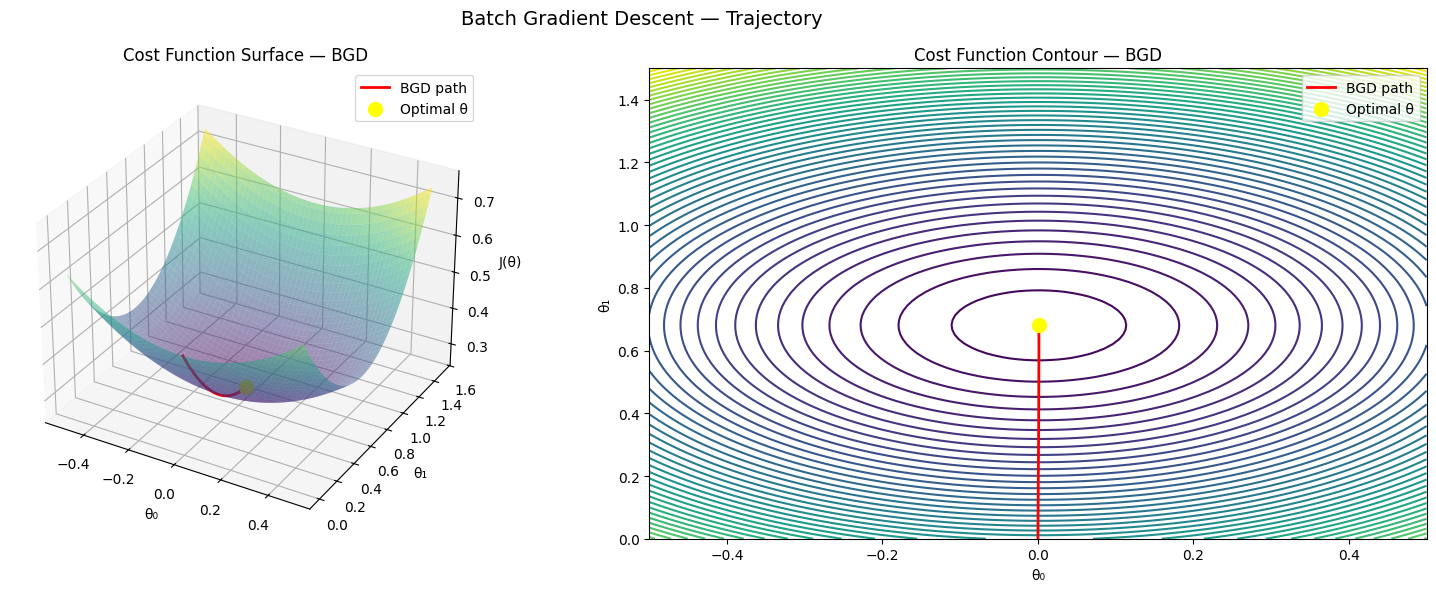

In [37]:
# Compute theta trajectory for plotting
theta_history_bgd = np.array(theta_history_bgd)

fig = plt.figure(figsize=(16, 6))

# 3D Surface + trajectory
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(T0, T1, J_grid, cmap="viridis", alpha=0.5)
ax1.plot(theta_history_bgd[:, 0], 
         theta_history_bgd[:, 1],
         [cost_function(X_train, y_train, t) for t in theta_history_bgd],
         color="red", linewidth=2, label="BGD path")
ax1.scatter(theta_ne[0], theta_ne[1],
            cost_function(X_train, y_train, theta_ne),
            color="yellow", s=100, zorder=5, label="Optimal θ")
ax1.set_xlabel("θ₀")
ax1.set_ylabel("θ₁")
ax1.set_zlabel("J(θ)")
ax1.set_title("Cost Function Surface — BGD")
ax1.legend()

# Contour + trajectory
ax2 = fig.add_subplot(122)
ax2.contour(T0, T1, J_grid, levels=50, cmap="viridis")
ax2.plot(theta_history_bgd[:, 0],
         theta_history_bgd[:, 1],
         color="red", linewidth=2, label="BGD path")
ax2.scatter(theta_ne[0], theta_ne[1],
            color="yellow", s=100, zorder=5, label="Optimal θ")
ax2.set_xlabel("θ₀")
ax2.set_ylabel("θ₁")
ax2.set_title("Cost Function Contour — BGD")
ax2.legend()

plt.suptitle("Batch Gradient Descent — Trajectory", fontsize=14)
plt.tight_layout()
plt.show()